In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from IPython.display import display, clear_output

#import and set up the autograder
import otter
grader = otter.Notebook("Reinforcement_learning.ipynb") # The name of the notebook is important if there are multiple notebooks in the folder!

<hr style="clear:both">

This notebook was written for the EPFL ME-390 course.

The image dataset is collected at [Sycamore](https://www.epfl.ch/labs/sycamore/) lab at EPFL.

**Author(s):** Gabriel Vallat

<hr style="clear:both">

# Reinforcement learning
Reinforcement learning (RL) is a type of machine learning where an agent learns to make decisions by taking actions in an environment to maximize cumulative reward. The agent interacts with the environment, receives feedback in the form of rewards or penalties, and adjusts its actions accordingly. The key components of reinforcement learning include: 
- **Agent**: The learner or decision maker.
- **Environment**: The external system the agent interacts with.
In this project, we will give you an environment, and you will implement an agent that learns to navigate this environment using REINFORCE, a policy gradient method.

## Environment
The environment is a grid world where the agent can move in four directions (up, down, left, right) and receives rewards based on its actions. The goal is to reach a target location while avoiding obstacles. We generated such an environment below. 
You will not need to modify this code, but you can read through it to understand how the environment works. 

The functions you will need to use are:
- `env.reset()`: Resets the environment to the initial state and returns the initial observation. and wether the initialization was successful.
- `env.step(action)`: Takes an action (0: up, 1: down, 2: left, 3: right) and returns a tuple (next_state, reward, done, info) where:
  - `next_state`: The next observation after taking the action.
  - `reward`: The reward received after taking the action.
  - `done`: A boolean indicating whether the episode has ended.
- `env.render()`: Renders the current state of the environment (optional, for visualization).
- `env.reseed()`: Reseeds the environment's random number generator: allows for reproducibility, and is used in the auto-grader.

```python

In [ ]:
#prepare the dataset
import shutil
import zipfile
import os
with zipfile.ZipFile('./dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('.')
try:
    shutil.rmtree("./dataset/.ipynb_checkpoints")
except:
    print("Dataset already clean")

In [ ]:
#state constants
EMPTY = 0
OBSTACLE = 1
AGENT = 2
GOAL = 3
#action constants
UP = 0
DOWN = 1
LEFT = 2
RIGHT = 3
env_colors = colors.ListedColormap(['white', 'black', 'blue', 'green'])

# define the environment
class Environment():
    def __init__(self,size,map=None,seed=None,base_reward=0,obstacle_cost=0.1,goal_reward=10):
        self.rng = np.random.default_rng(seed)
        if map is None:
            self.map = np.full(size,EMPTY,dtype=int)
        else:
            assert size == map.shape
            # the map is a binary image of obstacle location. 
            self.map = map.astype(int)
        self.current_loc = None
        self.goal_loc = None
        # the state is composed by the map of obstacles and the positions of the agent and of the goal (initialized later)
        self.state = self.map.copy()
        self.base_reward = base_reward
        self.obstacle_cost = obstacle_cost
        self.goal_reward = goal_reward
    def reseed(self,seed):
        self.rng = np.random.default_rng(seed)
    def reset(self, start_loc = None,goal_loc = None):
        # remove the current goal and agent position
        self.state = self.map.copy()
        if start_loc is None:
            # randomly chose the starting position of the agent, and place it in the map
            pot_loc = np.nonzero(self.state==EMPTY)
            loc = self.rng.choice(pot_loc[0].size)
            start_loc = (pot_loc[0][loc], pot_loc[1][loc])
            self.state[pot_loc[0][loc], pot_loc[1][loc]] = AGENT
        else:
            #place the agent at the given position
            if self.state[start_loc] == EMPTY:
                self.state[start_loc] = AGENT
            else:
                return False,self.map
        self.current_loc = np.array(start_loc)
        if goal_loc is None:
            # randomly chose the goal position of the agent, and place it in the map
            pot_loc = np.nonzero(self.state==EMPTY)
            loc = self.rng.choice(pot_loc[0].size)
            self.state[pot_loc[0][loc], pot_loc[1][loc]] = GOAL
            goal_loc = (pot_loc[0][loc], pot_loc[1][loc])
        else:
            #place the goal at the given position
            if self.state[goal_loc] == EMPTY:
                self.state[goal_loc] = GOAL
            else:
                return False,self.map
        self.goal_loc = np.array(goal_loc)
        return True,self.state.copy()
    def show(self):
        plt.imshow(self.state, cmap=env_colors, vmin=0, vmax=3)
        plt.xticks([])
        plt.yticks([])
        plt.show()
    def step(self, action):
        reward = self.base_reward
        info = {'hit_obstacle': False,
                'reached_goal': False}
        if self.current_loc is None:
            raise ValueError("Environment not reset. Call reset() before step().")
        #move the agent one step
        if action == UP:
            new_loc = self.current_loc + np.array([-1, 0])
        elif action == DOWN:    
            new_loc = self.current_loc + np.array([1, 0])
        elif action == LEFT:
            new_loc = self.current_loc + np.array([0, -1])
        elif action == RIGHT:
            new_loc = self.current_loc + np.array([0, 1])
        if (new_loc < 0).any() or (new_loc >= self.map.shape).any():
            info['hit_obstacle'] = True
            return self.state.copy(), reward-self.obstacle_cost, False,info
        if self.state[tuple(new_loc)] == OBSTACLE:
            info['hit_obstacle'] = True
            return self.state.copy(), reward-self.obstacle_cost, False,info
        if self.state[tuple(new_loc)] == GOAL:
            info['reached_goal'] = True
            self.state[tuple(self.current_loc)] = EMPTY
            self.state[tuple(new_loc)] = AGENT
            self.current_loc = new_loc
            return self.state.copy(), reward+self.goal_reward, True,info
        if self.state[tuple(new_loc)] == EMPTY:
            self.state[tuple(self.current_loc)] = EMPTY
            self.state[tuple(new_loc)] = AGENT
            self.current_loc = new_loc
            return self.state.copy(), reward, False,info

This environment can take an obstacle map as input. We provided you with an example, but feel free to create your own.

In [ ]:
obs_map = np.array([[0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
                    [0, 1, 1, 0, 0, 1, 0, 1, 1, 0],
                    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
                    [0, 1, 1, 1, 0, 0, 0, 1, 1, 0],
                    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
                    [0, 1, 1, 1, 0, 0, 0, 1, 1, 0],
                    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
                    [0, 1, 1, 1, 0, 0, 0, 1, 1, 0],
                    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
                    [0, 1, 1, 1, 0, 0, 0, 1, 1, 0]],dtype=int)
env = Environment((10,10),obs_map,seed=0)
env.show()

As you can see, only the obstacles are present in the state now. To add the agent and the goal to the state, we need to call the method `reset`

In [ ]:
#Call this cell twice. You should see two different results if env.reseed is commented out, and the same result if it is not.

#env.reseed(0)
env.reset()
env.show()

## QUESTION 1: Understanding the Environment
To test your understanding of the environment, you will have to implement an agent that takes random actions in it. We have provided you with the function `select_random_action(env)` that will select an action uniformly at random from the set of possible actions. 

Complete the function `random_rollout(env, max_steps=100)` that will run the random agent in the environment for a maximum of `max_steps` steps. The function should return the list of states, actions, and rewards encountered during the episode, and terminate the episode if the `done` flag is set to `True`.

In [ ]:
def render_notebook(env,title="",speed=0.01):
    """Render the environment dynamically in a notebook by clearing the output and re-displaying it.

    Args:
        env (Environment): The environment to render.
        title (str, optional): _description_. Defaults to "".
        speed (float, optional): Time each frame will be displayed. Defaults to 0.1.
    """
    clear_output(wait=True)
    env.show()
    plt.pause(speed)
def select_random_action(env):
    """Select a random action using the environment's random number generator.

    Args:
        env (Environmnent): The environment in wich the action will be taken.

    Returns:
        int: The selected action.
    """
    return env.rng.choice([UP, DOWN, LEFT, RIGHT])

def random_rollout(env,max_steps=100,show=True,seed=None):
    env.reseed(seed)
    valid,state = env.reset()
    done = False
    total_reward = 0
    steps = 0
    states = []
    actions = []
    rewards = []
    ...
    return states, actions, rewards
    

In [ ]:
# This function call should show a random rollout of the agent in a 5x5 environment: The blue agent should move randomly until it hits the green goal or reaches 5 steps.
env= Environment((5,5))
states,actions,rewards=random_rollout(env,5,show=True)

In [ ]:
grader.check("Random Rollout")

## QUESTION 2: Implementing a Learning Agent
Now that you have a basic understanding of the environment, you will implement an agent that maximizes its cumulative reward using the REINFORCE algorithm. 

As a reminder, the REINFORCE algorithm is computing:

$\nabla_\theta J(\theta)= \mathbb{E}_{\pi_\theta}\left[\sum_{t\in 0:T} \nabla_\theta\ln\pi_\theta(A_t\mid  S_t)(\sum_{\tau \in t:T} \gamma^\tau R_\tau)
 \Big|S_0 = s_0 \right]$

and is then using gradient ascent to update the weight of the policy.

$\theta_{t+1} \leftarrow \theta_t + \alpha\nabla_\theta J$

You will first need to implement the softmax function and its gradient. The softmax function is used to convert the agent's action preferences into a probability distribution over actions.

In [ ]:
def softmax(x):
    ...
def log_gradient_softmax(policy_logits:np.array,state:np.array,action:int):
    ...

In [ ]:
class Agent():
    def __init__(self,size, learning_rate=0.01, discount_factor=0.99,seed=None):
        self.rng = np.random.default_rng(seed)
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        # we use a softmax parametrization of the policy: each possible state is associated with a vector of 4 parameters, one per action.
        self.policy_logits = np.ones(([4 for i in range(np.prod(size))]+ [4])) # Uniform policy initialization

    def choose_action(self, state):
        # Don't hesitate to check how indexing works with numpy arrays. This is a very good way to optimize your code.
        return self.rng.choice([UP, DOWN, LEFT, RIGHT], p=softmax(self.policy_logits[tuple(state.flatten())]))
    def compute_reward_to_go(self, rewards):
        # Compute the discouted reward-to-go for each time step given the list of rewards.
        ...
    def update_policy(self, states, actions, rewards):
        # We shuffle the data to avoid correlations
        reward_to_go = self.compute_reward_to_go(rewards)
        shuffle_indices = self.rng.permutation(len(states))
        for i in shuffle_indices:
            # get each state, action and cummulative reward to update the policy according to REINFORCE
            ...
agent= Agent((3,3), learning_rate=0.01, discount_factor=0.99)

In [ ]:
grader.check("Learning agent")

## QUESTION 3: Training the Agent
Now that you have implemented the agent, you will let it interact with the environment and see it learn over time. You will implement the `train_fixed_target(env, agent, num_episodes=1000, max_steps_per_episode=100)` function that will train the agent for a specified number of episodes, and will be provided with different way to visualize the learning progress. 

One of the hardest tasks when implementing RL algorithms is to tune the hyperparameters and the reward function, but luckily, we have provided you with everything you'll need. You can experiment with different values if you wish, but it is not required.

In [ ]:
def train_fixed_target(env,agent, num_episodes=1000, max_steps=100,goal=(4, 4),starting_loc=None,print_stats=True):
    """Train an agent in a fixed target environment using the REINFORCE algorithm.

    Args:
        env (Environmnent): The training environment.
        agent (Agent): A trainable agent.
        num_episodes (int, optional): For how many episode the agent is trained. Defaults to 1000.
        max_steps (int, optional): If the episode is not finished after max_steps actions, end it and start over. Defaults to 100.
        goal (tuple, optional): position of the goal. Defaults to (4, 4).
        starting_loc (tuple, optional): Starting position of the agent. Defaults to None (random position).
        print_stats (bool, optional): Whether to print the success rate every 100 episode. Defaults to True.

    Returns:
        list[float], list[float],list[float]: total rewards,number of steps to reach the goal,and number of obstacles hit
    """
    average = 0
    total_rewards = []
    number_steps = []
    number_obstacles = []
    episode = 0
    while episode < num_episodes:
        states = []
        actions = []
        rewards = []
        done = False
        valid,state = env.reset(goal_loc=goal, start_loc=starting_loc)
        if not valid:
            #print("Invalid reset. Skipping episode.")
            if print_stats and episode % 100 == 0:
                print(f"Episode {episode}: Invalid reset. Skipping episode.")
                average = 0
            continue
        assert np.any(state == AGENT), "Agent not placed in the environment."
        total_reward = 0
        steps = 0
        nobs = 0
        # Run one episode using the agent's policy, collecting states, actions and rewards
        ...
        # Track success rate
        if info['reached_goal']:
            average += 1
        total_rewards.append(total_reward)
        number_steps.append(steps)
        number_obstacles.append(nobs)
        # Update the policy using the collected data
        ...
        if print_stats and episode % 100 == 0:
            print(f"Episode {episode}, number of success: {average}, Steps: {steps}")
            average = 0
        episode += 1
    return total_rewards,number_steps, number_obstacles

In [ ]:
# Train on a small environment to see if everything works as expected. You should see the number of successes increase over time.
env = Environment((3, 3),base_reward=0,seed=954)
agent=Agent(env.map.shape, learning_rate=0.05, discount_factor=0.99,seed=754)
total_rewards,nsteps,n_obstacles = train_fixed_target(env, agent, num_episodes=300, max_steps=10, goal=(2, 2))

Below are two functions allowing you to visualize the learning progress of your agent. The first function, `plot_learning_curve`, plots the total rewards obtained by the agent in each episode, how many steps it took and how many obstacle they hit, allowing you to see how the agent's performance improves over time. The second function, `test_agent`, visualizes the learned policy of the agent on the grid world.

In [ ]:
def plot_learning_curve(total_rewards,nsteps,nobstacles,smoothing=10):
    """Plot the learning curve of the agent.

    Args:
        total_rewards (list): List of total rewards per episode.
        nsteps (list): List of number of steps per episode.
        nobstacles (list): List of number of obstacles hit during the episodes.
    """
    fig,axs = plt.subplots(1,3,figsize=(15,4))

    x = np.arange(len(total_rewards))
    axs[0].plot(x,total_rewards,alpha=0.3,c='blue')
    average_reward =  np.convolve(total_rewards, np.ones(smoothing) / smoothing, mode='valid')
    xaverage = np.arange(smoothing-1,len(total_rewards))
    axs[0].plot(xaverage,average_reward,c='blue')
    plt.ylabel('Total Reward')
    axs[0].set_title('Total Reward per Episode')
    axs[0].set_ylabel('Total Reward')
    axs[0].legend(['Episode Reward',f'Rolling average (smoothing={smoothing})'])

    axs[1].plot(x,nsteps,alpha=0.3,c='orange')
    average_steps =  np.convolve(nsteps, np.ones(smoothing) / smoothing, mode='valid')
    xaverage = np.arange(smoothing-1,len(nsteps))
    axs[1].plot(xaverage,average_steps,c='orange')
    axs[1].set_title('Number of Steps per Episode')
    axs[1].set_ylabel('Number of Steps')
    axs[1].legend(['Episode Steps',f'Rolling average (smoothing={smoothing})'])

    axs[2].plot(x,nobstacles,alpha=0.3,c='red')
    average_obstacles =  np.convolve(nobstacles, np.ones(smoothing) / smoothing, mode='valid')
    xaverage = np.arange(smoothing-1,len(nobstacles))
    axs[2].plot(xaverage,average_obstacles,c='red')
    axs[2].set_title('Number of Obstacles Hit per Episode')
    axs[2].set_ylabel('Number of Obstacles Hit')
    axs[2].legend(['Episode Obstacles',f'Rolling average (smoothing={smoothing})'])
    [ax.set_xlabel('Episode') for ax in axs]
    fig.tight_layout()
    plt.show()
plot_learning_curve(total_rewards,nsteps,n_obstacles,smoothing=10)

In [ ]:
def test_agent(env,agent,max_steps=100,goal_pos=(2, 2),start_pos =(0, 0),show=True,print_steps=False):
    valid,state = env.reset(goal_loc=goal_pos, start_loc=start_pos)
    assert valid, "Invalid reset. Check the environment and goal location."
    done = False
    total_reward = 0
    steps = 0
    while not done and steps < max_steps:
        action = agent.choose_action(state)
        state, reward, done,info = env.step(action)
        total_reward += reward
        steps += 1
        if print_steps:
            print(f"Step: {steps}, Action: {action}, Reward: {reward}, Total Reward: {total_reward}, Done: {done}")
        if show:
            render_notebook(env, f"Step {steps}, Action {action}, Reward {reward}")
    return info['reached_goal'], total_reward, steps

In [ ]:
test_agent(env, agent, max_steps=100)

What happens when you try to increase the size of the environmnent? Uncomment the following lines to see the results.

In [ ]:
#Agent((5,5), learning_rate=0.01, discount_factor=0.99, seed=42)

## QUESTION 4: Feature Extraction

In this project, we will not implement use neural networks to parametrize the policy. Instead, we will use a fixed obstacle map, which means that we could simply extract 2 features: the agent's position and the goal position.You will first have to implement the `extract_features` function below that does this, and then to use it in a new type of agent, using the previous one as a template.

In [ ]:
def extract_features(state):
    """Extract the agent's position and the goal position from the state.

    Args:
        state (np.ndarray): State of the environment.

    Returns:
        np.ndarray: a (4,) array containing the agent's (y,x) position and the goal's (y, x) position.
    """
    ...
    return features
def get_prob(policy_logits, features):
    """Takes the policy parameters (called logits) for the given features and returns the corresponding action probabilities using a softmax.

    Args:
        policy_logits (np.ndarray): The policy parameters
        features (np.ndarray): The features to index the policy.

    Returns:
        np.ndarray: probabilities of each action in the given state.
    """
    ...
class AgentFeature(Agent):
    def __init__(self,size, learning_rate=0.01, discount_factor=0.99,seed=None):
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.rng = np.random.default_rng(seed=seed)
        # Uniform policy initialization
        self.policy_logits = ...
    
    def choose_action(self, state):
        #extract the agent's position from the state
        features = extract_features(state)
        # get the action probabilities
        p = get_prob(self.policy_logits,features)
        return self.rng.choice([UP, DOWN, LEFT, RIGHT], p=p)
    def update_policy(self, states, actions, rewards):
        shuffle_indices = self.rng.permutation(len(states))
        reward_to_go = self.compute_reward_to_go(rewards) #Reuse the method from parent class
        for i in shuffle_indices:
            #Implement the learning rule here
            ...
# Additional way of visualizing the policy
def visulalize_pol(policy, obstacle_map,goal_pos=(9,9)):
    """Shows the policy as arrows on the obstacle map.
    Args:
        policy (np.ndarray): The policy to visualize.
        obstacle_map (np.ndarray): the obstacle map.
        goal_pos (tuple, optional): The goal position. Defaults to (9,9).
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    obstacle_map = obstacle_map.copy()
    obstacle_map[goal_pos] = GOAL
    ax.imshow(obstacle_map, cmap=env_colors,vmax=3)
    
    ax.set_xticks([])
    ax.set_yticks([])
    for i in range(obstacle_map.shape[0]):
        for j in range(obstacle_map.shape[1]):
            if obstacle_map[i, j] == OBSTACLE or (i == goal_pos[0] and j == goal_pos[1]):
                continue
            action_probs = get_prob(policy, np.array([i,j,goal_pos[0],goal_pos[1]]))
            ax.annotate("", xytext=(j, i),xy=(j+(0.5*(action_probs[RIGHT] - action_probs[LEFT])), i+0.5*(-action_probs[UP] + action_probs[DOWN])),
                        arrowprops=dict(arrowstyle="->"))
    plt.show()

In [ ]:

af = AgentFeature((3,3), learning_rate=0.005, discount_factor=0.9)
env = Environment((3, 3))
tot_rewards,nsteps,nobs = train_fixed_target(env, af, num_episodes=1000, max_steps=10, goal=(2, 2))


In [ ]:
visulalize_pol(af.policy_logits, np.zeros((3,3),dtype=int),goal_pos=(2,2))

In [ ]:
plot_learning_curve(tot_rewards,nsteps,nobs,smoothing=100)

This agent should perform similarly to the previous one, but it will be able to handle bigger environments.

In [ ]:
grader.check("Feature-based agent")

## QUESTION 5: Testing in a Larger Environment
Now that we have a working agent, we can test it in a bigger environment. 

In [ ]:
# test your agent with the given obs_map
env = ...
af = AgentFeature((10,10), learning_rate=0.001, discount_factor=0.99)
# The full training takes 50000 episodes
tot_rewards_large,n_steps_large,n_obstacles_large = train_fixed_target(env, af, num_episodes=5000, max_steps= 50, goal=(9, 9))

In [ ]:
visulalize_pol(af.policy_logits, obs_map, goal_pos=(9, 9))

In [ ]:
plot_learning_curve(tot_rewards_large,n_steps_large,n_obstacles_large,smoothing=100)


Your graph should look something like this:

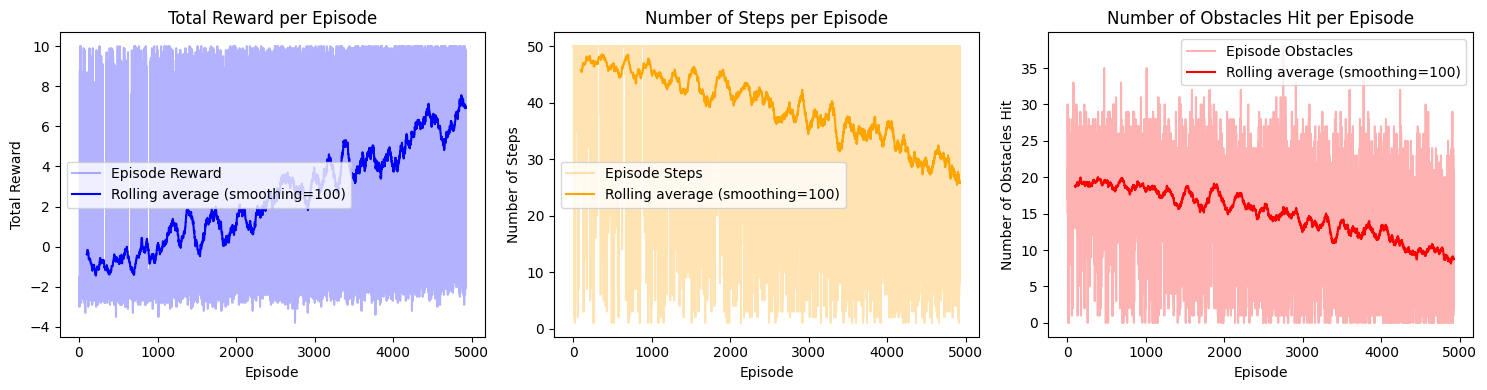

In [ ]:
grader.check("Large scale")

You should be able to get some results, but not great ones. To improve our agent, we will give it a better initialization: We will allow it to detect the nearby obstacles and avoid direct collisions. We will first use the ground truth obstacle map, and then you will use your own image classifier from last project to detect them.

In [ ]:
class AgentSensors(AgentFeature):
    def __init__(self, size, obstacle_map=None, learning_rate=0.01, discount_factor=0.99):
        super().__init__(size, learning_rate, discount_factor)
        self.obstacle_map = obstacle_map  # Placeholder for the obstacle map
        self.set_initial_policy()
    def set_initial_policy(self,p_obstacle=-1e3):
        """Set the probability of moving into an obstacle (or outside of the map) to a very low value. 

        Args:
            p_obstacle (float, optional): Initial logits (inputs of the softmax function) for obstacles. Defaults to -1e3.
        """
        if self.obstacle_map is None:
            return
        #keep the agent in the map:
        self.policy_logits[0,:,:,:,UP]=p_obstacle
        self.policy_logits[-1,:,:,:,DOWN]=p_obstacle
        self.policy_logits[:,0,:,:,LEFT]=p_obstacle
        self.policy_logits[:,-1,:,:,RIGHT]=p_obstacle
        # Initialize the policy based on the obstacle map
        ...

In [ ]:
asens = AgentSensors((10,10), obstacle_map=obs_map, learning_rate=0.0001, discount_factor=0.99)

The agent should now be able to never hit any obstacle, without any training.

In [ ]:
test_agent(env, asens, max_steps=100,goal_pos=(9, 9))

In [ ]:
grader.check("Sensor-based agent")

Now our agent simply have to learn to get to the goal, so the training should be much faster.

In [ ]:
agent_sensors = AgentSensors((10, 10), obstacle_map=obs_map, learning_rate=0.01, discount_factor=0.9)
env = Environment((10, 10), obs_map, seed=42)
reward_sensor,n_steps_sensor, n_obstacles_sensor= train_fixed_target(env, agent_sensors, num_episodes=500, max_steps= 50, goal=(9, 9))

In [ ]:
plot_learning_curve(reward_sensor,n_steps_sensor,n_obstacles_sensor,smoothing=100)

In [ ]:
test_agent(env, agent_sensors, max_steps=50,goal_pos=(9, 9))

In [ ]:
visulalize_pol(agent_sensors.policy_logits, obs_map,goal_pos=(9,9))

The results should be better than before. However, we considered that our map was perfect. Let's now use your classifier to create an obstacle map.

## QUESTION 6: Using an Image Classifier for Obstacle Detection
In this final question, we will load your previously trained image classifier to detect obstacles in the environment. You will need to modify the `AgentSensors` to use your classifier results instead of the ground truth obstacle map. 

The file `best_model_example.pth` does not use the same architecture as your model (it is based on resnet18) so you should not try to load its weights. 

In [ ]:
unknown_env = Environment((10,10),np.load("./dataset/secret_obs_map.npy"),seed=0)
unknown_env.show()

In [ ]:
import shutil
import zipfile
import os
with zipfile.ZipFile('./dataset/img.zip', 'r') as zip_ref:
    zip_ref.extractall('./dataset')
try:
    shutil.rmtree("./dataset/img/.ipynb_checkpoints")
except:
    print("Dataset already clean")

In [ ]:
# Load the best model (best_model_example.pth) and predict the gridworld (probability of each cell being blocked or free)
import torch
from torchvision import models, transforms
from PIL import Image
import os

class AgentSensorsNN(AgentSensors):
    def __init__(self, size, best_model_path, img_path, learning_rate=0.01, discount_factor=0.99):
        super().__init__(size, learning_rate=learning_rate, discount_factor=discount_factor,obstacle_map=None)
        # Initialize your model here and generate obstacle_map by checking the images in the dataset
        
        #Define your model architecture
        model = ...
        ...
        # Load your best model
        model.load_state_dict(torch.load(best_model_path, map_location=torch.device('cpu')))
        model.eval()
        predictions = []
        for img_name in os.listdir(img_path):
            img_path_f = os.path.join(img_path, img_name)
            img = torch.tensor(np.array(Image.open(img_path_f)).astype(np.float32) / 255.0).unsqueeze(0).permute(0,3,1,2)  # Add batch dimension
            with torch.no_grad():
                ...
        # Convert predictions to a grid
        predicted_grid = ...
        # save the probability given by your neural network
        self.predicted_grid = predicted_grid
        # save most likely class to create the map
        obstacle_map = ...
        
        self.obstacle_map = obstacle_map  # Placeholder for the obstacle map
        self.set_initial_policy(-100)


In [ ]:
best_model_path = "./best_model_example.pth"
img_path = "./dataset/img"
agent_sensor = AgentSensors((10,10),(unknown_env.state==OBSTACLE).astype(int) , learning_rate=0.01, discount_factor=0.99)
agent_sensor_NN = AgentSensorsNN((10,10), best_model_path, img_path, learning_rate=0.01, discount_factor=0.99)
plt.imshow(agent_sensor_NN.obstacle_map, cmap=env_colors,vmax=3)
agent_nosensor = AgentFeature((10,10), learning_rate=0.01, discount_factor=0.99)


In [ ]:
reward_gt,steps_gt, obs_gt = train_fixed_target(unknown_env, agent_sensor, num_episodes=500, max_steps= 50, goal=(9, 9))

In [ ]:
reward_nn, steps_nn, obs_nn = train_fixed_target(unknown_env, agent_sensor_NN, num_episodes=500, max_steps= 50, goal=(9, 9))

In [ ]:
reward_plain,steps_plain,obs_plain = train_fixed_target(unknown_env, agent_nosensor, num_episodes=500, max_steps= 50, goal=(9, 9))

In [ ]:
def compare_learning_curve(total_rewards,nsteps,nobstacles,names,smoothing=10):
    """Plot the learning curve of the agent.

    Args:
        total_rewards (np.ndarray): List of total rewards per episode.
        nsteps (list): List of number of steps per episode.
        nobstacles (list): List of number of obstacles hit during the episodes.
    """
    fig,axs = plt.subplots(1,3,figsize=(15,4))

    average_reward =  np.vstack([np.convolve(total_rewards_serie, np.ones(smoothing) / smoothing, mode='valid') for total_rewards_serie in total_rewards])
    xaverage = np.tile(np.arange(smoothing-1,total_rewards.shape[1]),(3,1))
    axs[0].plot(xaverage.T,average_reward.T)
    plt.ylabel('Total Reward')
    axs[0].set_title('Total Reward per Episode')
    axs[0].set_ylabel('Total Reward')
    axs[0].legend(names)

    average_steps =  np.vstack([np.convolve(nsteps_serie, np.ones(smoothing) / smoothing, mode='valid') for nsteps_serie in nsteps])
    axs[1].plot(xaverage.T,average_steps.T)
    axs[1].set_title('Number of Steps per Episode')
    axs[1].set_ylabel('Number of Steps')
    axs[0].legend(names)

    average_obs =  np.vstack([np.convolve(nobs_serie, np.ones(smoothing) / smoothing, mode='valid') for nobs_serie in nobstacles])
    axs[2].plot(xaverage.T,average_obs.T)
    axs[2].set_title('Number of Obstacles per Episode')
    axs[2].set_ylabel('Number of Obstacles Hit')
    axs[0].legend(names)
    [ax.set_xlabel('Episode') for ax in axs]
    fig.tight_layout()
    plt.show()
rewards = np.vstack([reward_gt,reward_nn,reward_plain])
steps = np.vstack([steps_gt,steps_nn,steps_plain])
obstacles = np.vstack([obs_gt,obs_nn,obs_plain])
names = ['Ground Truth','Neural Network','No Sensor']
compare_learning_curve(rewards,steps,obstacles,names,smoothing=100)

In [ ]:
visulalize_pol(agent_sensor_NN.policy_logits, obstacle_map=(unknown_env.state==OBSTACLE).astype(int),goal_pos=(9,9))
visulalize_pol(agent_nosensor.policy_logits, obstacle_map=(unknown_env.state==OBSTACLE).astype(int),goal_pos=(9,9))


In [ ]:
grader.check("NN Agent")

Congratulations! You have successfully implemented a reinforcement learning agent that can navigate a grid world environment. Here is a few things you might keep in mind for future projects:
- Extracting relevant features can boost the performance of your agent.
- A good initialization can significantly speed up the training process.
- A lot of things can be learned by RL, but an even greater number of things don't need to be. Whenever you have the chance to manually provide some information to your agent, do it!